Number of rows after cleaning: 336


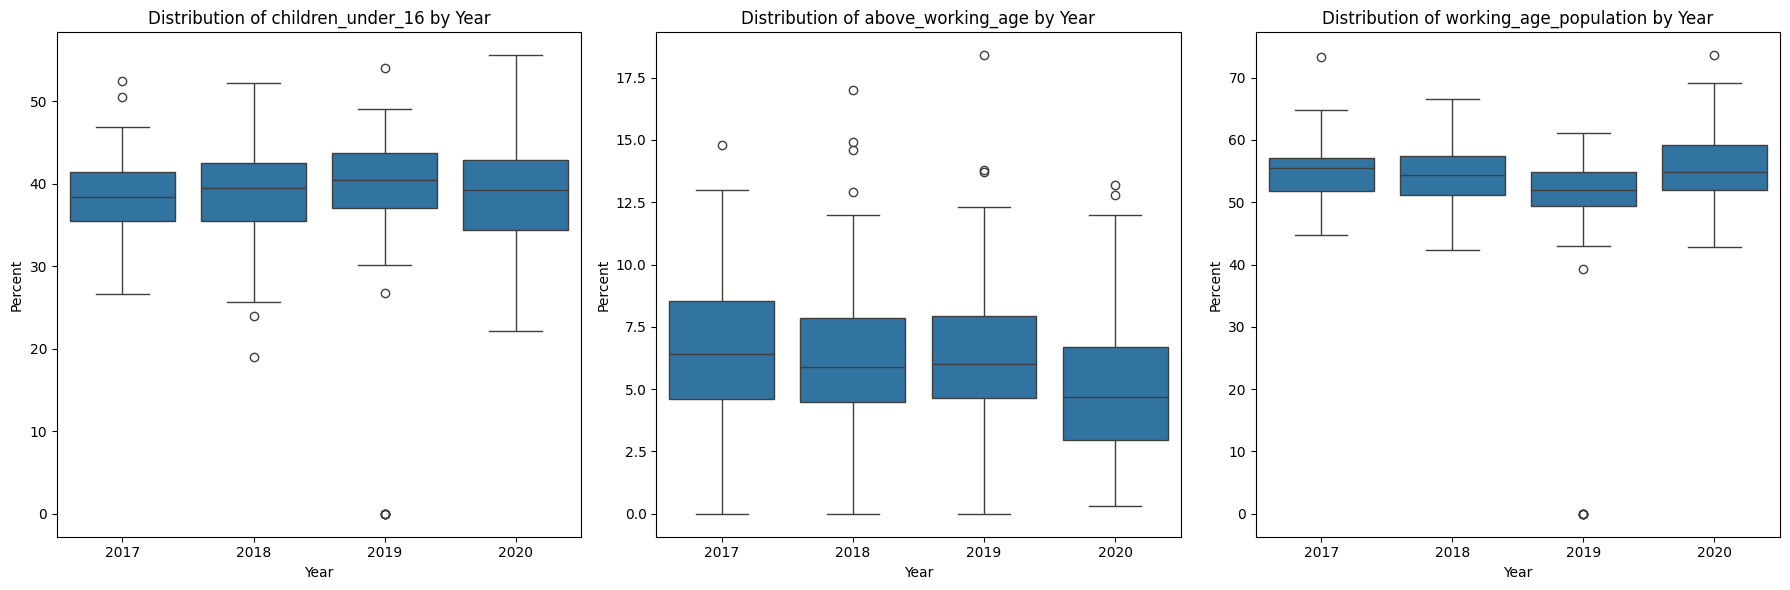

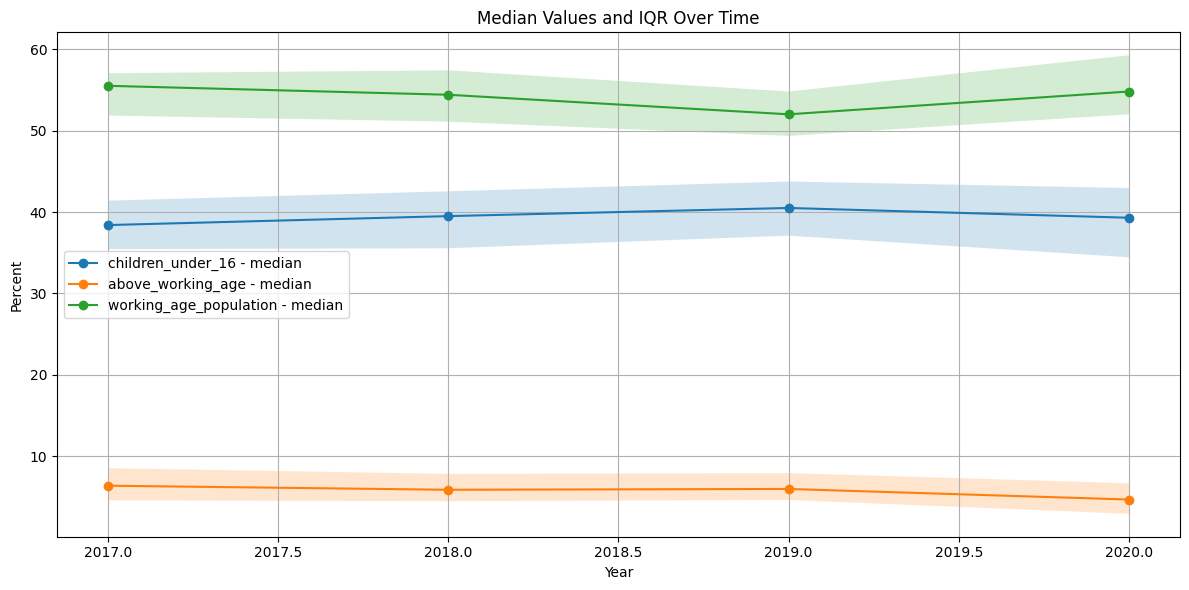

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
file_path = "../../outputs/standardized_datasets/poverty_socdem_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()]

# 3. Rename columns for readability
df = df.rename(columns={
    "Дети в возрасте до 16 лет": "children_under_16",
    "Население старше трудоспособного возраста": "above_working_age",
    "Население трудоспособного возраста": "working_age_population"
})

# 4. Convert selected columns to numeric
numeric_cols = [
    "children_under_16",
    "above_working_age",
    "working_age_population"
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# 5. Remove rows with missing values
df = df.dropna(subset=numeric_cols)

print(f"Number of rows after cleaning: {len(df)}")

# 6. Boxplots by year
plt.figure(figsize=(18,6))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x="year", y=col, data=df)
    plt.title(f"Distribution of {col} by Year")
    plt.xlabel("Year")
    plt.ylabel("Percent")

plt.tight_layout()
plt.show()

# 7. Median and IQR by year
plt.figure(figsize=(12,6))
for col in numeric_cols:
    grouped = df.groupby("year")[col]
    med = grouped.median()
    q1 = grouped.quantile(0.25)
    q3 = grouped.quantile(0.75)

    plt.plot(med.index, med.values, marker="o", label=f"{col} - median")
    plt.fill_between(med.index, q1.values, q3.values, alpha=0.2)

plt.title("Median Values and IQR Over Time")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# EDA of `poverty_socdem_standardized.csv`

## Data Description
- Approximately 340 observations after filtering and removing missing values.
- Time coverage: 2017–2020.
- Key variables:
  - share of children (under 16)
  - share of working-age population
  - share of population above working age

---

## Data Types
- All variables are correctly formatted and converted to numeric types.

---

## Missing Values
- Initially, 12 missing values were detected across the three main columns.
- These observations were removed to ensure consistency of the analysis.

---

## Key Observations
- The share of children across most regions ranges between ~35–42%.  
- The share of population above working age is relatively stable, around ~5–6%.  
- The working-age population accounts for approximately ~54% on average.  

These distributions suggest a relatively stable demographic structure across regions, but with noticeable variation that may influence socio-economic outcomes.

---

## Interpretation
- Regions with a higher share of dependents (children and elderly) may experience greater economic pressure.
- Differences in population structure can affect labor supply, income levels, and overall regional vulnerability.
- Even moderate variation in these indicators may contribute to meaningful differences between regions.

---

## Conclusion
The dataset is clean and suitable for further analysis.

Demographic indicators provide an important structural perspective and are expected to play a supporting role in clustering, complementing economic variables such as income and poverty.

In [2]:
df.to_csv("../../data/clean/socdem_AfterEDA.csv", index=False)